1. Analyze and Preprocess data - Check if the dataset has missing values or has any other problem.
2. Feature Engineering
3. Divide the dataset into 2 training and test sets
4. Use Pipeline
    4. a. Use scaler and dimensional reduction (if it is necessary).
    4. b. Use suitable Naive Bayes for this problem.
5. Perform model on training set and test set using gridsearch CV
6. Measure performance of the model.
7. Which metric is your main metric for this problem and why? What are your scaler, dimensional reduction and naive bayes model as well as their params? (<= 200 words, also input your opinion or conclusion here)


How can I measure your point:
1. Your function is callable and runs correctly
2. The performance of your model (in full pipeline) is acceptable. The final error based on my train and test set is low enough.
3. The data preprocessing is correct or make sense
4. The Feature engineering is correct or make sense
5. Any other additional process will be considered a small plus point.

A Travel Company Is Offering Travel Insurance Packages To Their Customers. The new insurance plan also covers Covid-19. The Company Claims To Know Which Customers Are Interested To Buy It Based On The Company's Database History.

* Age - Age Of The Customer
* Employment Type - The Sector In Which Customer Is Employed
GraduateOrNot - Whether The Customer Is College Graduate Or Not
* AnnualIncome - The Yearly Income Of The Customer In Indian Rupees
* FamilyMembers - Number Of Members In Customer's Family
* ChronicDisease - Whether The Customer Suffers From Any Major Disease Or Conditions Like Diabetes/High BP or Asthama,etc.
* FrequentFlyer - Derived Data Based On Customer's History Of Booking Air Tickets On Atleast 4 Different Instances In The Last 2 Years (2017-2019).
* EverTravelledAbroad - Has The Customer Ever Travelled To A Foreign Country
* TravelInsurance - Did The Customer Buy Travel Insurance Package During Introductory Offering Held In The Year 2019.

**Submit Link**: https://forms.gle/CwmpBrfa2SYQic7G6

## Load Dataset

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from google.colab import drive

# drive.mount("/content/drive")

In [173]:
import pandas as pd
PATH = r"D:\Introduction-to-Machine-Learning_MTH10353\Homework\3\TravelInsurancePrediction.csv" # Path to your file

df = pd.read_csv(PATH)
df.head()
#ToDo: Show histogram of dataframe

,Unnamed: 0,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,0,31,Government Sector,Yes,400000,6,1,No,No,0
1,1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


## Data Analysis

In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1987 entries, 0 to 1986
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           1987 non-null   int64 
 1   Age                  1987 non-null   int64 
 2   Employment Type      1987 non-null   object
 3   GraduateOrNot        1987 non-null   object
 4   AnnualIncome         1987 non-null   int64 
 5   FamilyMembers        1987 non-null   int64 
 6   ChronicDiseases      1987 non-null   int64 
 7   FrequentFlyer        1987 non-null   object
 8   EverTravelledAbroad  1987 non-null   object
 9   TravelInsurance      1987 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 155.4+ KB


In [175]:
df.describe()

,Unnamed: 0,Age,AnnualIncome,FamilyMembers,ChronicDiseases,TravelInsurance
count,1987.000000,1987.000000,1.987000e+03,1987.000000,1987.000000,1987.000000
mean,993.000000,29.650226,9.327630e+05,4.752894,0.277806,0.357323
std,573.741812,2.913308,3.768557e+05,1.609650,0.448030,0.479332
min,0.000000,25.000000,3.000000e+05,2.000000,0.000000,0.000000
25%,496.500000,28.000000,6.000000e+05,4.000000,0.000000,0.000000
50%,993.000000,29.000000,9.000000e+05,5.000000,0.000000,0.000000
75%,1489.500000,32.000000,1.250000e+06,6.000000,1.000000,1.000000
max,1986.000000,35.000000,1.800000e+06,9.000000,1.000000,1.000000


In [ ]:
for column in df.columns:
    if df[column].nunique() <= 10:
        print(f"Unique values for column '{column}': {df[column].unique()}")
        

Unique values for column 'Employment Type': ['Government Sector' 'Private Sector/Self Employed']
Unique values for column 'GraduateOrNot': ['Yes' 'No']
Unique values for column 'FamilyMembers': [6 7 4 3 8 9 5 2]
Unique values for column 'ChronicDiseases': [1 0]
Unique values for column 'FrequentFlyer': ['No' 'Yes']
Unique values for column 'EverTravelledAbroad': ['No' 'Yes']
Unique values for column 'TravelInsurance': [0 1]


In [177]:
print("Missing values:")
df.isnull().sum()

Missing values:


Unnamed: 0             0
Age                    0
Employment Type        0
GraduateOrNot          0
AnnualIncome           0
FamilyMembers          0
ChronicDiseases        0
FrequentFlyer          0
EverTravelledAbroad    0
TravelInsurance        0
dtype: int64

In [178]:
print("Invalid values:")
print(df[df["Age"] < 0])
print(df[df["AnnualIncome"] < 0])
print(df[df["FamilyMembers"] < 0])
print(df[df["ChronicDiseases"] < 0])
print(df[df["TravelInsurance"] < 0])

Invalid values:
Empty DataFrame
Columns: [Unnamed: 0, Age, Employment Type, GraduateOrNot, AnnualIncome, FamilyMembers, ChronicDiseases, FrequentFlyer, EverTravelledAbroad, TravelInsurance]
Index: []
Empty DataFrame
Columns: [Unnamed: 0, Age, Employment Type, GraduateOrNot, AnnualIncome, FamilyMembers, ChronicDiseases, FrequentFlyer, EverTravelledAbroad, TravelInsurance]
Index: []
Empty DataFrame
Columns: [Unnamed: 0, Age, Employment Type, GraduateOrNot, AnnualIncome, FamilyMembers, ChronicDiseases, FrequentFlyer, EverTravelledAbroad, TravelInsurance]
Index: []
Empty DataFrame
Columns: [Unnamed: 0, Age, Employment Type, GraduateOrNot, AnnualIncome, FamilyMembers, ChronicDiseases, FrequentFlyer, EverTravelledAbroad, TravelInsurance]
Index: []
Empty DataFrame
Columns: [Unnamed: 0, Age, Employment Type, GraduateOrNot, AnnualIncome, FamilyMembers, ChronicDiseases, FrequentFlyer, EverTravelledAbroad, TravelInsurance]
Index: []


Remove the column Unnamed: 0 because we don't need it for our analysis. It is just an index column

In [179]:
# remove column Unnamed: 0
df = df.drop(columns=["Unnamed: 0"])
df.head()

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,31,Government Sector,Yes,400000,6,1,No,No,0
1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


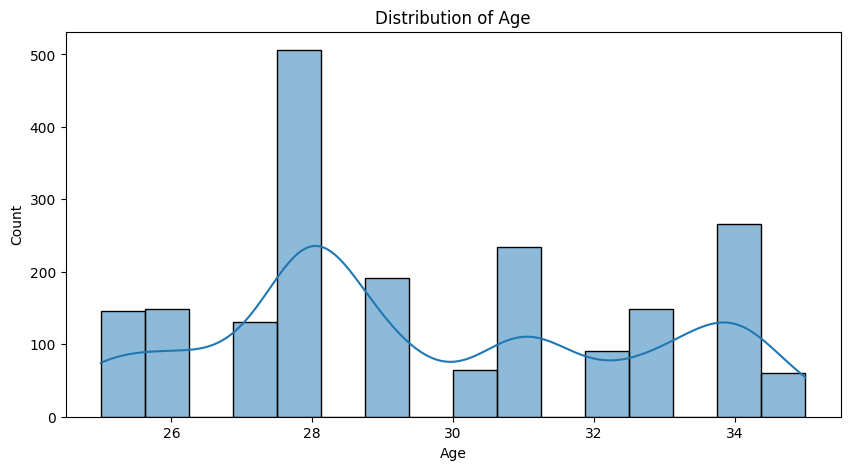

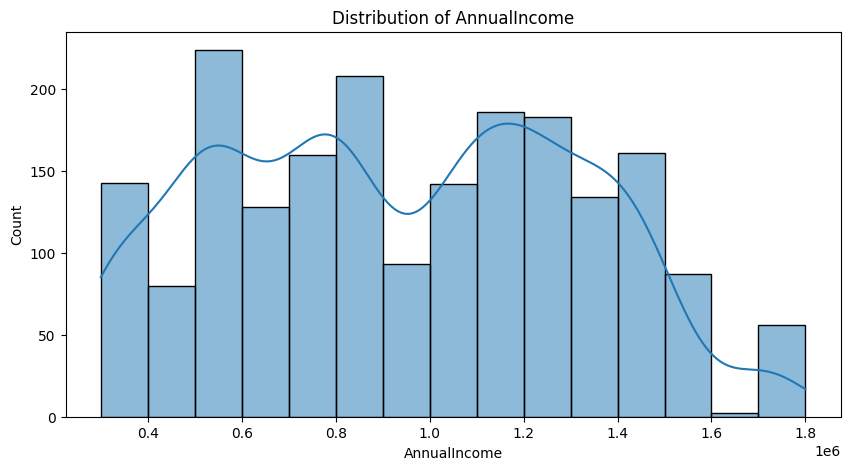

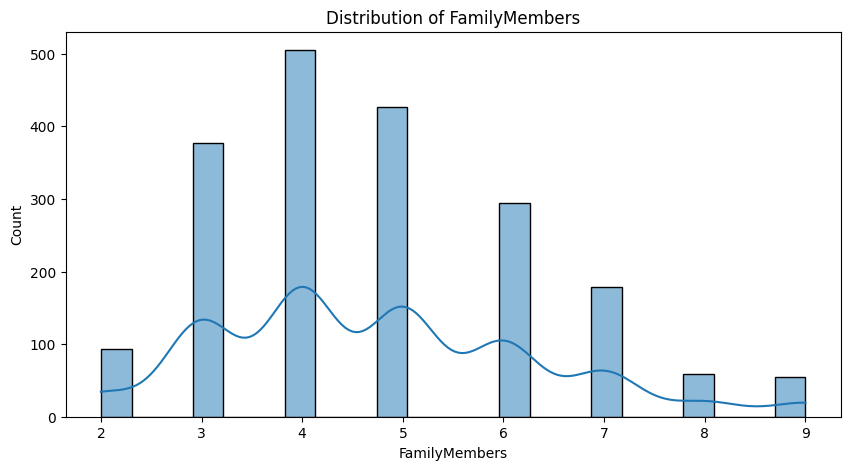

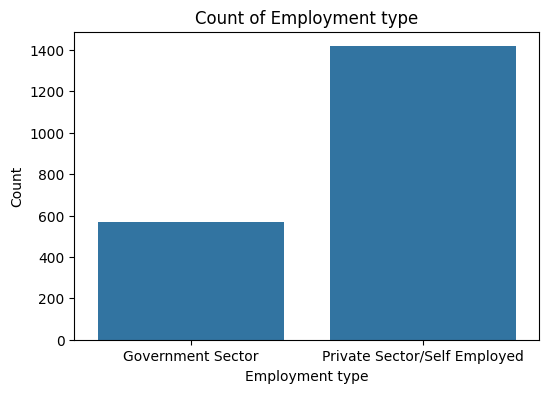

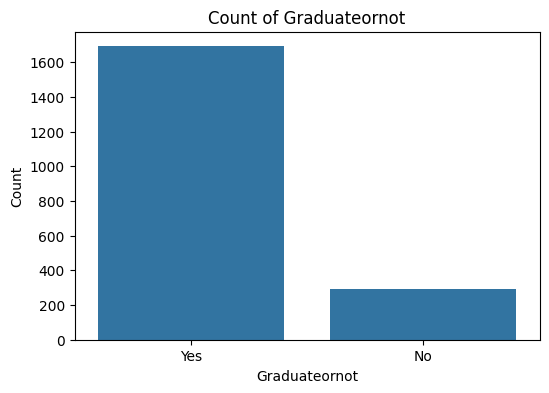

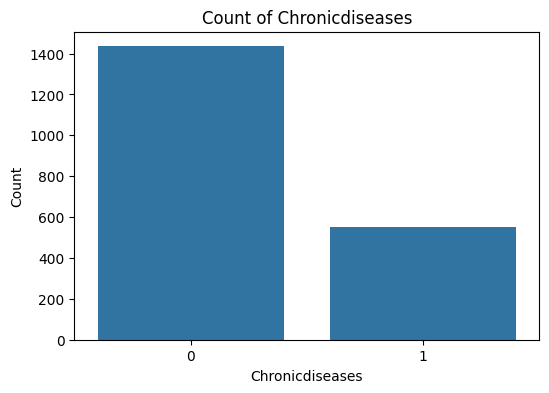

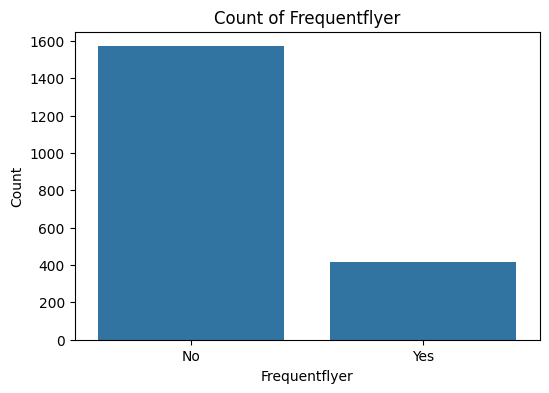

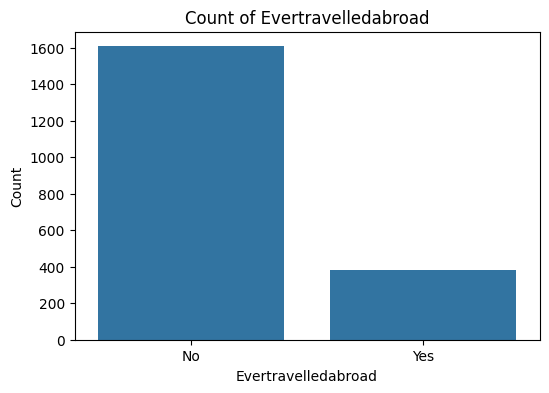

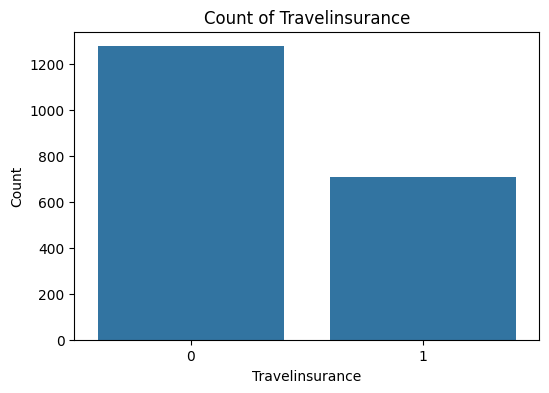

In [180]:
from matplotlib import pyplot as plt
import seaborn as sns


non_binary_columns = [col for col in df.columns if df[col].nunique() > 2]
for column in non_binary_columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[column], kde=True)
    plt.title(f"Distribution of {column}")
    plt.show()

binary_columns = [col for col in df.columns if df[col].nunique() == 2]
for column in binary_columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=df[column])
    plt.title(f'Count of {column.capitalize()}')
    plt.xlabel(column.capitalize())
    plt.ylabel('Count')
    plt.show()



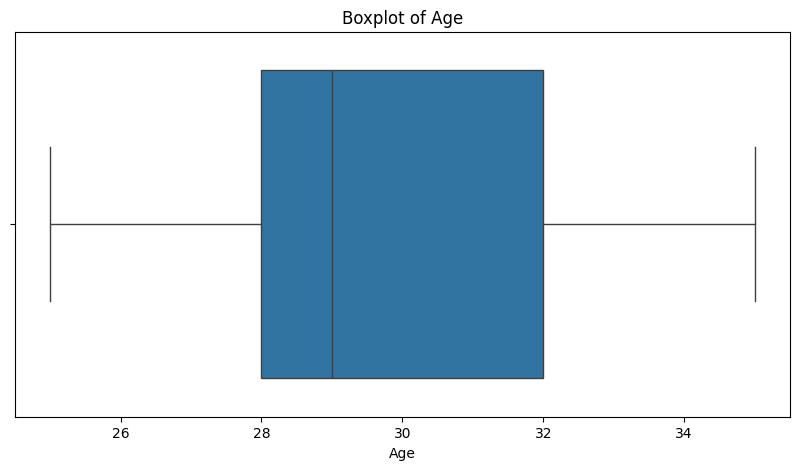

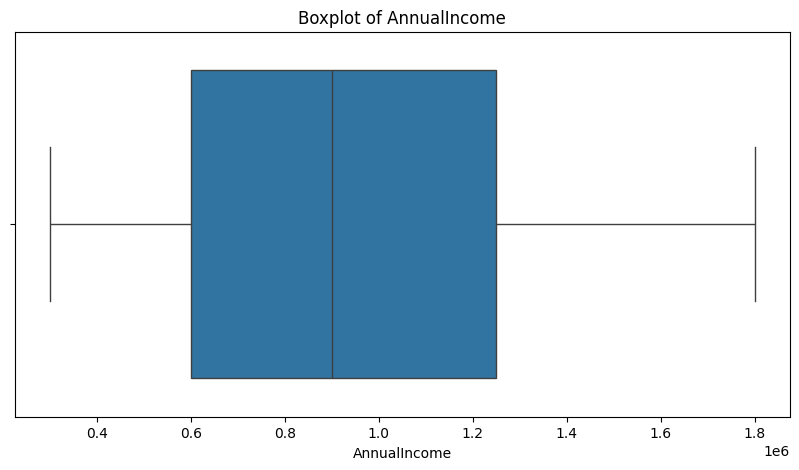

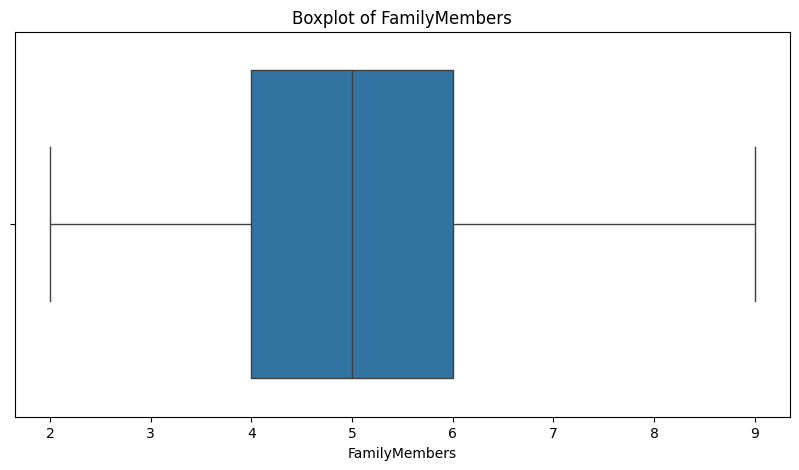

In [181]:
for column in non_binary_columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()
    

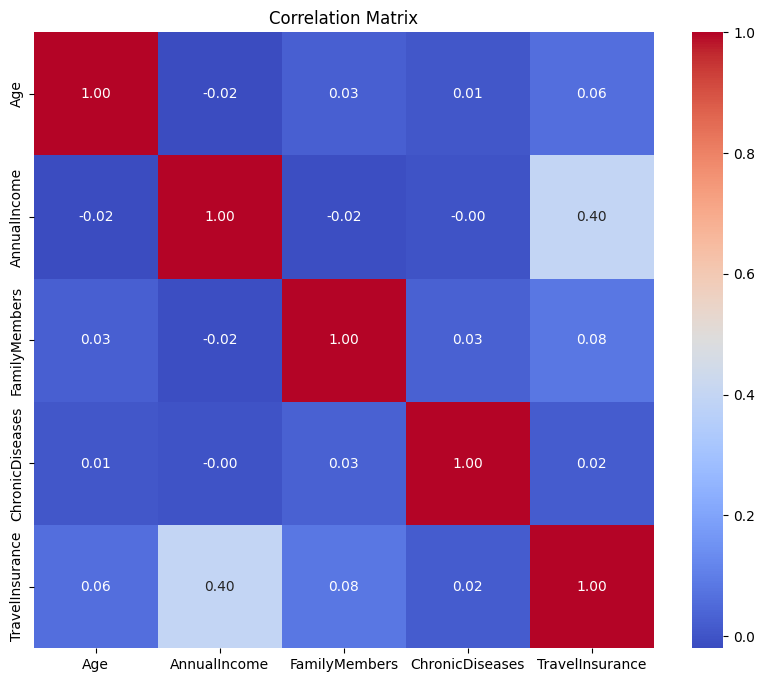

In [182]:
plt.figure(figsize=(10,8))

# Tính ma trận tương quan giữa các biến số
numerical_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numerical_cols].corr()

# Heatmap để visualize tương quan
# annot=True: hiển thị giá trị
# cmap='coolwarm': chọn màu
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

## Preprocessing

In [183]:
def preprocessing_data(df):
    """
    Preprocess your data (eg. Drop null datapoints or fill missing data)
    :param df: pandas DataFrame
    :return: pandas DataFrame
    """
    # Todo: preprocess data
    df = df.dropna() # Drop rows with missing values
    return df

In [184]:
df = preprocessing_data(df.copy())

## Feature Engineering

<Axes: >

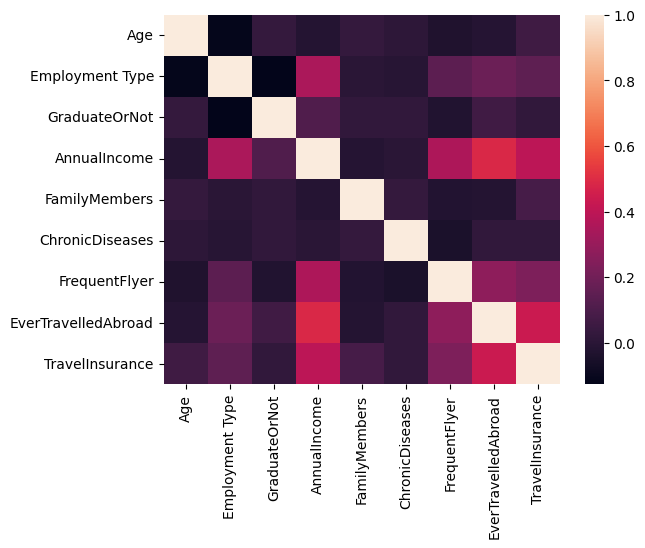

In [185]:
# Heatmap
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

def apply_feature_engineering(df):
    """
    Apply all feature engineering to transform your data into number
    :param df: pandas DataFrame
    :return: pandas DataFrame
    """
    # Todo: Normalize your data
    # Non numeric columns to numeric
    label_encoder = LabelEncoder()
    for column in df.columns:
        if df[column].dtype == 'object':
            df[column] = label_encoder.fit_transform(df[column])
        else:
            df[column] = (df[column] - df[column].min()) / (df[column].max() - df[column].min())
    return df

df = apply_feature_engineering(df)
sns.heatmap(df.corr()) # Show heatmap after normalized data

In [186]:
def prepare_X_y(df):
    """
    Feature engineering and create X and y
    :param df: pandas dataframe
    :return: (X, y) output feature matrix (dataframe), target (series)
    """
    # Todo: Split data into X and y (using sklearn train_test_split). Return two dataframes
    X = df.drop(['TravelInsurance'], axis=1)
    y = df['TravelInsurance']
    return X, y

X, y = prepare_X_y(df)

# Apply machine learning model

## Train-test split

In [187]:
from sklearn.model_selection import train_test_split
RANDOM_STATE = 69 # funny number
TRAIN_SIZE = 0.7

trainX, testX ,trainY, testY = train_test_split(X, y, train_size=TRAIN_SIZE, random_state=RANDOM_STATE)

## Build SK-learn model

In [188]:
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

def build_model(X, y):
    """
    Design your model and train it (including your best params)
    :param X: feature matrix
    :param y: target
    :return: a model
    """
    # Using StandardScaler to normalize data, PCA for dimensionality reduction, and GaussianNB as the classifier
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA()), 
        ('nb', GaussianNB())
    ])
    
    # GridSearch 
    # var_smoothing helps NB handle numerical stability; n_components tunes PCA (from None to 8 because we have 8 features)
    param_grid = {
        'pca__n_components': [None, 2, 4, 6, 8],
        'nb__var_smoothing': np.logspace(-10, -3, 8)
    }
    grid_search = GridSearchCV(estimator=pipe, param_grid=param_grid, cv=5, scoring='f1_weighted')
    
    # Fit the model with X, y
    grid_search.fit(X, y)
    print(f"Best parameters found: {grid_search.best_params_}")
    
    # Return fitted pipeline (best)
    return grid_search.best_estimator_
def calculate_performance(y_true, y_pred):
    """
    :param y_true: ground truth values
    :param y_pred: predictions
    :return: main_score
    """
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"precision: {prec:.4f}")
    print(f"recall: {rec:.4f}")
    print(f"accuracy: {acc:.4f}")
    print(f"F1: {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

    # Todo: Only choose one of them as your score for the question 7
    main_score = f1
    return main_score

model = build_model(trainX, trainY)
# Compare on training dataset
pred = model.predict(testX)
calculate_performance(testY, pred)

Best parameters found: {'nb__var_smoothing': np.float64(1e-10), 'pca__n_components': 6}
precision: 0.7812
recall: 0.7772
accuracy: 0.7772
F1: 0.7655

Classification Report:
               precision    recall  f1-score   support

         0.0       0.77      0.92      0.84       373
         1.0       0.80      0.54      0.65       224

    accuracy                           0.78       597
   macro avg       0.79      0.73      0.74       597
weighted avg       0.78      0.78      0.77       597



0.7654640152328595

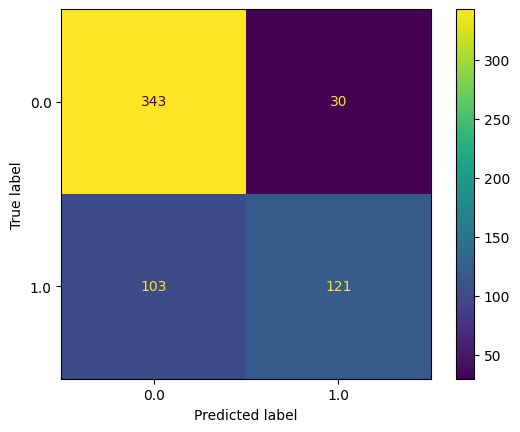

In [192]:
cm = confusion_matrix(testY,pred)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_).plot()


In [ ]:
def get_conclusion():
    # Todo: Please return your answer, conclusion and opinion right here
    return (
        "7. My main metric is the F1-score because it perfectly balances precision and recall, which is crucial given our imbalanced dataset (373 vs 224 samples). "
        "Scaler is StandardScaler because it centers the data and scales it to unit variance => good for PCA and Naive Bayes to function optimally. "
        "Dimensional reduction is PCA, which not only reduces noise but creates uncorrelated components, perfectly satisfying the feature independence assumption of Naive Bayes. "
        "Model is GaussianNB, suited for continuous data. "
        "Best parameters found: {'nb__var_smoothing': 1e-10, 'pca__n_components': 6}. "
        "Conclusion: The model performs best with minimal variance smoothing and retaining 6 principal components. However, it struggles slightly with the minority class (Class 1 recall: 0.54)"
    )